In [2]:
import json
import os
import pandas as pd

folder_path = r"C:\Users\dell\Desktop\Projects using DS\ipl_json"

all_balls = []

for file in os.listdir(folder_path):
    if file.endswith(".json"):
        with open(os.path.join(folder_path, file), 'r') as f:
            data = json.load(f)
            
            match_id = file.replace('.json', '')
            innings_list = data.get('innings', [])
            
            for innings in innings_list:
                team = innings.get('team', '')
                overs = innings.get('overs', [])
                
                for over in overs:
                    over_num = over.get('over', 0)
                    deliveries = over.get('deliveries', [])
                    
                    for delivery in deliveries:
                        # Wicket info
                        wicket = 0
                        player_out = ''
                        if 'wickets' in delivery:
                            wicket = 1
                            player_out = delivery['wickets'][0].get('player_out', '')
                        
                        ball = {
                            'match_id': match_id,
                            'batting_team': team,
                            'over': over_num,
                            'batter': delivery.get('batter', ''),
                            'bowler': delivery.get('bowler', ''),
                            'runs_batter': delivery['runs'].get('batter', 0),
                            'runs_extras': delivery['runs'].get('extras', 0),
                            'runs_total': delivery['runs'].get('total', 0),
                            'wicket': wicket,
                            'player_out': player_out
                        }
                        all_balls.append(ball)

balls_df = pd.DataFrame(all_balls)
print(f"Total balls: {len(balls_df)}")
balls_df.head(10)


Total balls: 295732


,match_id,batting_team,over,batter,bowler,runs_batter,runs_extras,runs_total,wicket,player_out
0,1082591,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,0,0,0,
1,1082591,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,0,0,0,
2,1082591,Sunrisers Hyderabad,0,DA Warner,TS Mills,4,0,4,0,
3,1082591,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,0,0,0,
4,1082591,Sunrisers Hyderabad,0,DA Warner,TS Mills,0,2,2,0,
5,1082591,Sunrisers Hyderabad,0,S Dhawan,TS Mills,0,0,0,0,
6,1082591,Sunrisers Hyderabad,0,S Dhawan,TS Mills,0,1,1,0,
7,1082591,Sunrisers Hyderabad,1,S Dhawan,A Choudhary,1,0,1,0,
8,1082591,Sunrisers Hyderabad,1,DA Warner,A Choudhary,4,0,4,0,
9,1082591,Sunrisers Hyderabad,1,DA Warner,A Choudhary,0,1,1,0,


In [3]:
# Batting Stats
batting_stats = balls_df.groupby('batter').agg(
    total_runs=('runs_batter', 'sum'),
    total_balls=('runs_batter', 'count'),
).reset_index()

# Dismissals — player_out se nikalo
dismissals = balls_df[balls_df['player_out'] == balls_df['batter']].groupby('player_out').size().reset_index()
dismissals.columns = ['batter', 'dismissals']

# Merge karo
batting_stats = batting_stats.merge(dismissals, on='batter', how='left')
batting_stats['dismissals'] = batting_stats['dismissals'].fillna(0).astype(int)

# Strike Rate aur Average
batting_stats['strike_rate'] = (batting_stats['total_runs'] / batting_stats['total_balls'] * 100).round(2)
batting_stats['average'] = (batting_stats['total_runs'] / batting_stats['dismissals'].replace(0, 1)).round(2)

# Top 10 batters
print(batting_stats.sort_values('total_runs', ascending=False).head(10).to_string(index=False))

        batter  total_runs  total_balls  dismissals  strike_rate  average
       V Kohli        9346         7127         229       131.14    40.81
     RG Sharma        7331         5659         244       129.55    30.05
      S Dhawan        6769         5483         187       123.45    36.20
     DA Warner        6567         4849         158       135.43    41.56
      KL Rahul        5828         4302         125       135.47    46.62
      SK Raina        5536         4177         162       132.54    34.17
      MS Dhoni        5439         4101         139       132.63    39.13
     AM Rahane        5367         4391         172       122.23    31.20
AB de Villiers        5181         3487         122       148.58    42.47
     SV Samson        5181         3770         159       137.43    32.58


In [4]:
# Bowling Stats
bowling_stats = balls_df.groupby('bowler').agg(
    total_balls=('runs_total', 'count'),
    total_runs=('runs_total', 'sum'),
    total_wickets=('wicket', 'sum')
).reset_index()

# Overs calculate karo
bowling_stats['overs'] = (bowling_stats['total_balls'] / 6).round(1)

# Economy Rate
bowling_stats['economy'] = (bowling_stats['total_runs'] / bowling_stats['overs']).round(2)

# Bowling Average
bowling_stats['bowling_avg'] = (bowling_stats['total_runs'] / bowling_stats['total_wickets'].replace(0, 1)).round(2)

# Top 10 wicket takers
print(bowling_stats.sort_values('total_wickets', ascending=False).head(10).to_string(index=False))

     bowler  total_balls  total_runs  total_wickets  overs  economy  bowling_avg
    B Kumar         4769        6045            243  794.8     7.61        24.88
  YS Chahal         4167        5501            242  694.5     7.92        22.73
  SP Narine         4730        5379            229  788.3     6.82        23.49
  JJ Bumrah         3792        4582            208  632.0     7.25        22.03
   DJ Bravo         3296        4436            207  549.3     8.08        21.43
   R Ashwin         4868        5721            205  811.3     7.05        27.91
  PP Chawla         3895        5179            201  649.2     7.98        25.77
  RA Jadeja         4329        5525            189  721.5     7.66        29.23
 SL Malinga         2974        3486            188  495.7     7.03        18.54
Rashid Khan         3585        4390            187  597.5     7.35        23.48


In [5]:
batting_stats.to_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\batting_stats.csv", index=False)
bowling_stats.to_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\bowling_stats.csv", index=False)
print("Saved!")

Saved!


In [6]:
import pandas as pd

balls_df = pd.read_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_balls.csv")
matches_df = pd.read_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_final.csv")

print("Balls match_id sample :" , balls_df['match_id'].head())
print("Matches match_id sample : ", matches_df['match_id'].head())

Balls match_id sample : 0    1082591
1    1082591
2    1082591
3    1082591
4    1082591
Name: match_id, dtype: int64
Matches match_id sample :  0    1082591
1    1082592
2    1082593
3    1082594
4    1082595
Name: match_id, dtype: int64


In [7]:
latest_match_id = matches_df['match_id'].iloc[-1]
print(f"Latest Match ID:{latest_match_id}")

match_info = matches_df[matches_df['match_id'] == latest_match_id].iloc[0]
print(f"Teams: {match_info['team1']} vs {match_info['team2']}")
print(f"Winner: {match_info['winner']}")
print(f"Venue: {match_info['venue']}")

Latest Match ID:981019
Teams: Royal Challengers Bangalore vs Sunrisers Hyderabad
Winner: Sunrisers Hyderabad
Venue: M Chinnaswamy Stadium


In [8]:
# Us match ka ball-by-ball data nikalo
match_balls = balls_df[balls_df['match_id'] == latest_match_id]

# Over-by-over runs calculate karo — dono teams ke liye
over_scores = match_balls.groupby(['batting_team', 'over'])['runs_total'].sum().reset_index()

print(over_scores.head(20))

                   batting_team  over  runs_total
0   Royal Challengers Bangalore     0           5
1   Royal Challengers Bangalore     1          13
2   Royal Challengers Bangalore     2           8
3   Royal Challengers Bangalore     3          16
4   Royal Challengers Bangalore     4          13
5   Royal Challengers Bangalore     5           4
6   Royal Challengers Bangalore     6          10
7   Royal Challengers Bangalore     7          10
8   Royal Challengers Bangalore     8          21
9   Royal Challengers Bangalore     9          12
10  Royal Challengers Bangalore    10           8
11  Royal Challengers Bangalore    11           9
12  Royal Challengers Bangalore    12          12
13  Royal Challengers Bangalore    13           8
14  Royal Challengers Bangalore    14           9
15  Royal Challengers Bangalore    15           4
16  Royal Challengers Bangalore    16          10
17  Royal Challengers Bangalore    17           7
18  Royal Challengers Bangalore    18          12


Royal Challengers Bangalore Total: 200
Sunrisers Hyderabad Total: 208


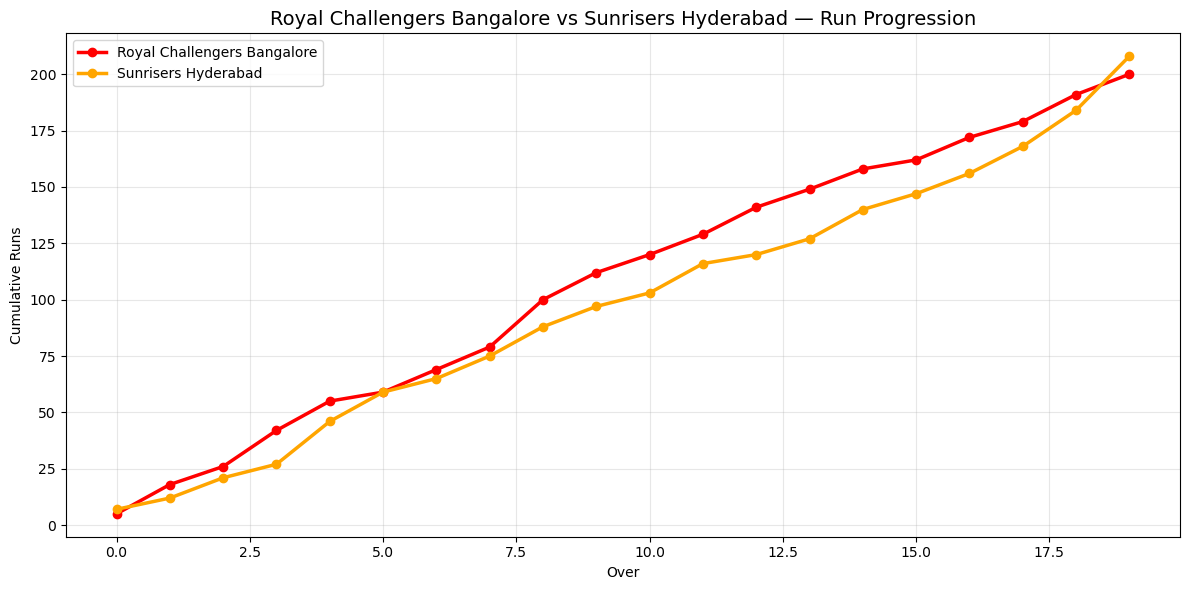

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Dono teams ka data alag karo
team1 = match_info['team1']  # RCB
team2 = match_info['team2']  # SRH

rcb_scores = over_scores[over_scores['batting_team'] == team1].copy()
srh_scores = over_scores[over_scores['batting_team'] == team2].copy()

# Cumulative score nikalo (running total)
rcb_scores['cumulative'] = rcb_scores['runs_total'].cumsum()
srh_scores['cumulative'] = srh_scores['runs_total'].cumsum()

# Total scores
rcb_total = rcb_scores['cumulative'].iloc[-1]
srh_total = srh_scores['cumulative'].iloc[-1]

print(f"{team1} Total: {rcb_total}")
print(f"{team2} Total: {srh_total}")

# Graph banao
plt.figure(figsize=(12, 6))
plt.plot(rcb_scores['over'], rcb_scores['cumulative'], 
         color='red', linewidth=2.5, marker='o', label=team1)
plt.plot(srh_scores['over'], srh_scores['cumulative'], 
         color='orange', linewidth=2.5, marker='o', label=team2)

plt.title(f'{team1} vs {team2} — Run Progression', fontsize=14)
plt.xlabel('Over')
plt.ylabel('Cumulative Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\run_progression.png")
plt.show()

In [12]:
# Over-by-over cumulative score
over_scores = match_balls.groupby(['batting_team', 'over'])['runs_total'].sum().reset_index()

# Teams alag karo
rcb_scores = over_scores[over_scores['batting_team'] == team1].copy()
srh_scores = over_scores[over_scores['batting_team'] == team2].copy()

# Cumulative sum
rcb_scores['cumulative'] = rcb_scores['runs_total'].cumsum()
srh_scores['cumulative'] = srh_scores['runs_total'].cumsum()

In [14]:
balls_df = pd.read_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_balls.csv")
print(balls_df.columns.tolist())
print(balls_df.head())

['match_id', 'batting_team', 'over', 'batter', 'bowler', 'runs_batter', 'runs_extras', 'runs_total', 'wicket']
   match_id         batting_team  over     batter    bowler  runs_batter  \
0   1082591  Sunrisers Hyderabad     0  DA Warner  TS Mills            0   
1   1082591  Sunrisers Hyderabad     0  DA Warner  TS Mills            0   
2   1082591  Sunrisers Hyderabad     0  DA Warner  TS Mills            4   
3   1082591  Sunrisers Hyderabad     0  DA Warner  TS Mills            0   
4   1082591  Sunrisers Hyderabad     0  DA Warner  TS Mills            0   

   runs_extras  runs_total  wicket  
0            0           0       0  
1            0           0       0  
2            0           4       0  
3            0           0       0  
4            2           2       0  


In [15]:
matches_df = pd.read_csv(r"C:\Users\dell\Desktop\Projects using DS\ipl_json\ipl_final.csv")

#Findd soecific match— MI vs CSK 2019 mein
team1 = 'Mumbai Indians'
team2 = 'Chennai Super Kings'
season = 2019

# Matching matches 
h2h = matches_df[
    ((matches_df['team1'] == team1) & (matches_df['team2'] == team2) |
    (matches_df['team1'] == team2) & (matches_df['team2'] == team1)) &
    (matches_df['season'] == season)
]

print(f"Total matches found: {len(h2h)}")
print(h2h[['match_id', 'team1', 'team2', 'winner', 'season']])

Total matches found: 4
     match_id                team1                team2          winner  \
131   1175370       Mumbai Indians  Chennai Super Kings  Mumbai Indians   
160   1178419       Mumbai Indians  Chennai Super Kings  Mumbai Indians   
171   1181764  Chennai Super Kings       Mumbai Indians  Mumbai Indians   
174   1181768       Mumbai Indians  Chennai Super Kings  Mumbai Indians   

     season  
131    2019  
160    2019  
171    2019  
174    2019  


Match: Mumbai Indians vs Chennai Super Kings
Winner: Mumbai Indians
Venue: Wankhede Stadium


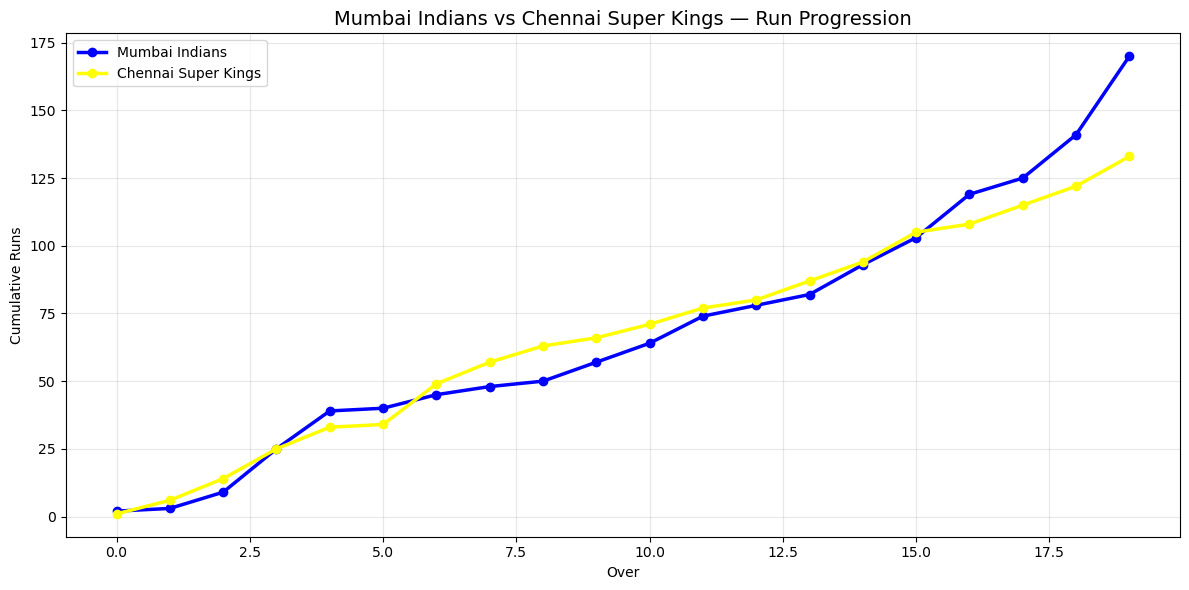

In [16]:
import matplotlib.pyplot as plt

# Pehla match 
match_id = h2h.iloc[0]['match_id']
match_info = h2h.iloc[0]

print(f"Match: {match_info['team1']} vs {match_info['team2']}")
print(f"Winner: {match_info['winner']}")
print(f"Venue: {match_info['venue']}")

# Us match ka ball-by-ball data
match_balls = balls_df[balls_df['match_id'] == match_id]

# Over-by-over runs
over_scores = match_balls.groupby(['batting_team', 'over'])['runs_total'].sum().reset_index()

# Dono teams alag kare
team1_scores = over_scores[over_scores['batting_team'] == match_info['team1']].copy()
team2_scores = over_scores[over_scores['batting_team'] == match_info['team2']].copy()

# Cumulative score
team1_scores['cumulative'] = team1_scores['runs_total'].cumsum()
team2_scores['cumulative'] = team2_scores['runs_total'].cumsum()

# Graph banaya
plt.figure(figsize=(12, 6))
plt.plot(team1_scores['over'], team1_scores['cumulative'],
         color='blue', linewidth=2.5, marker='o', label=match_info['team1'])
plt.plot(team2_scores['over'], team2_scores['cumulative'],
         color='yellow', linewidth=2.5, marker='o', label=match_info['team2'])

plt.title(f"{match_info['team1']} vs {match_info['team2']} — Run Progression", fontsize=14)
plt.xlabel('Over')
plt.ylabel('Cumulative Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()